## Homework 7 - due Friday, April 10th by 4 PM 

Name: Kristen Townsend

In [1]:
# Use this cell to import all necessary packages for the assignment 
import math
import numpy as np
import matplotlib.pyplot as plt

### Problem 1: Exercise 8.1, page 341

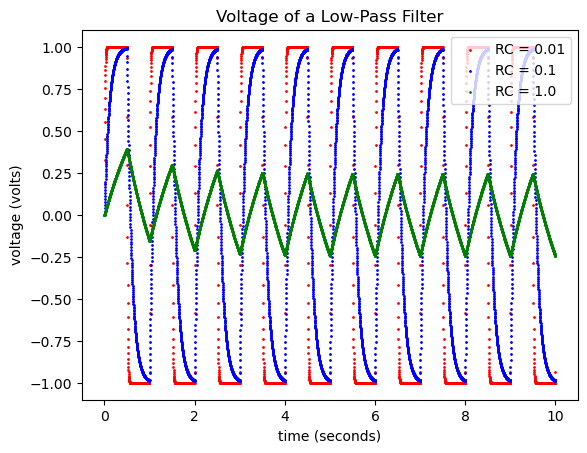

In [2]:
# part a
# define functions
def V_in(t):
    time_check = math.floor(2*t)

    # check even or odd
    if time_check%2 == 0:
        v = 1
    else:
        v = -1
    return v

def f(V_out, t):
    return 1/RC * (V_in(t) - V_out)

# constants
t1 = 0.0 # start of interval
t2 = 10.0 # end of interval
N = 5000 # number of steps
h = (t2-t1)/N #size of a single step

# different values of RC
RC1 = 0.01
RC2 = 0.1
RC3 = 1.0

tpts = np.arange(t1, t2+h, h)

# need to keep values for all 3 RC's
Vpts1 = []
Vpts2 = []
Vpts3 = []

# for RC = 0.01
V_out = 0.0 # initial 
RC = RC1
for t in tpts:
    Vpts1.append(V_out)
    k1 = h*f(V_out, t)
    k2 = h*f(V_out+0.5*k1, t+0.5*h)
    k3 = h*f(V_out+0.5*k2, t+0.5*h)
    k4 = h*f(V_out+k3, t+h)
    V_out += (k1+2*k2+2*k3+k4)/6

# for RC = 0.1
V_out = 0.0 # initial 
RC = RC2
for t in tpts:
    Vpts2.append(V_out)
    k1 = h*f(V_out, t)
    k2 = h*f(V_out+0.5*k1, t+0.5*h)
    k3 = h*f(V_out+0.5*k2, t+0.5*h)
    k4 = h*f(V_out+k3, t+h)
    V_out += (k1+2*k2+2*k3+k4)/6

# for RC = 1.0
V_out = 0.0 # initial 
RC = RC3
for t in tpts:
    Vpts3.append(V_out)
    k1 = h*f(V_out, t)
    k2 = h*f(V_out+0.5*k1, t+0.5*h)
    k3 = h*f(V_out+0.5*k2, t+0.5*h)
    k4 = h*f(V_out+k3, t+h)
    V_out += (k1+2*k2+2*k3+k4)/6

# plotting results
plt.scatter(tpts,Vpts1, color="red", s=1)
plt.scatter(tpts,Vpts2, color="blue", s=1)
plt.scatter(tpts,Vpts3, color="green", s=1)
plt.legend(["RC = 0.01","RC = 0.1", "RC = 1.0"])
plt.xlabel("time (seconds)")
plt.ylabel("voltage (volts)")
plt.title("Voltage of a Low-Pass Filter")

plt.show()


##### Explanation: 

When defining the function needed to solve the differential equation in part (a), I created a conditional within the definition to determine the value of $V_in$ depending on if the rounded floor of $2t$ was even or odd.

To accomplish this I used the function math.floor() from the math library and checked if the value was even or odd with a simple modulo devision by 2. This creates an initial square-wave behavior.

Three different values of $RC$ were used to apply the 4th order Runge-Kutta method. These different values required the Runge-Kutta to be run three different times, and all three results are plotted against time on the same plot to provide easy comparison. The red plot corresponds to $RC = 0.01$, $RC = 0.1$, and $RC = 1.0$.

For part (b), my thoughts are as follows: The circuit is acting as a low-pass filter. These filters only allow below a specific audio frequency, in this case voltage, to pass through while reducing the signals with higher frequencies and are typically used in sound systems.

With this interpretation in mind, the variable $RC$ seems to be the aspect most in constrol of the voltage limiting, as altering this value changed nothing about the oscillatory periods. The smaller the value of $RC$, the more sharply defined the square wave appears to be and vice-versa. When $RC = 1.0$, the amplitude of the oscillations is sharply damped as the current passing through the system moves 'sluggishly.' The amplitude of the voltage may correspond with audio volume? If this is the case, the best option for audio seems to be $RC = 0.1$, as the system maintains clarity of sound by reaching the maximum amplitude (voltage) while scrubbing unincluded frequencies.

### Problem 2: Exercise 8.3, page 348

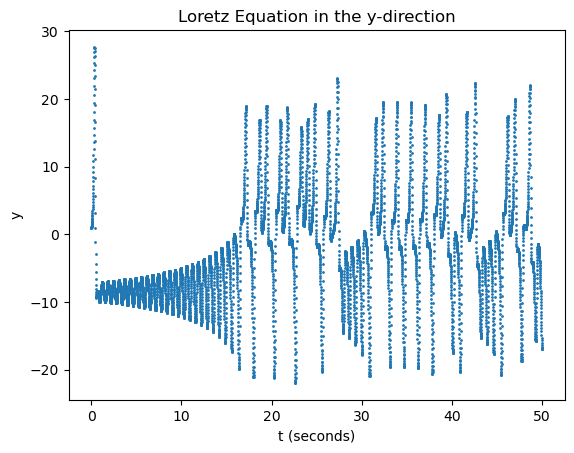

In [3]:
# part a
# defining functions
def f(r,t):
    # r = np.array([x,y])
    x = r[0]
    y = r[1]
    z = r[2]

    # define actual differential equations
    fx = sigma*(y-x)
    fy = R*x - y - x*z
    fz = x*y - b*z

    # return vector array of functions
    return np.array([fx,fy,fz], float)

# define constants
tstart = 0.0
tend = 50.0
N = 7000
h = (tend-tstart) / N
sigma = 10
R = 28
b = 8/3

# time array
tpts = np.arange(tstart, tend+h, h)

r = np.array([0,1,0], float) # initial conditions
xpts = np.zeros(len(tpts))
ypts = np.zeros(len(tpts))
zpts = np.zeros(len(tpts))

# loop to apply fourt-order rune-kutta
for i in range(len(tpts)):
    xpts[i] = r[0]
    ypts[i] = r[1]
    zpts[i] = r[2]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
# only y as a function of time
plt.scatter(tpts,ypts, s=1)
plt.xlabel("t (seconds)")
plt.ylabel("y")
plt.title("Loretz Equation in the y-direction")

plt.show()

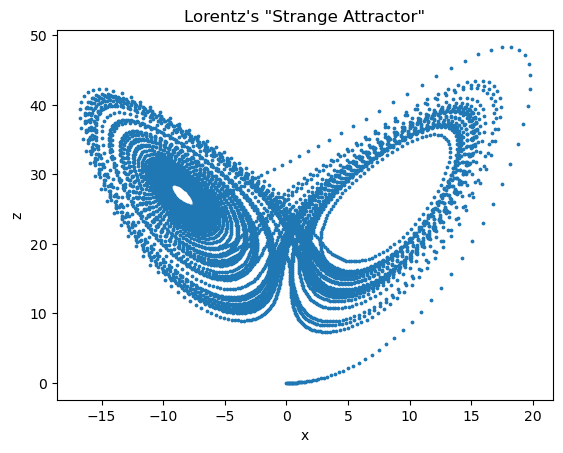

In [4]:
# part b
# z against x
plt.scatter(xpts,zpts,s=3)
plt.xlabel("x")
plt.ylabel("z")
plt.title('Lorentz\'s "Strange Attractor"')

plt.show()

#### Explanation: 

As with any of these problems, for part (a) I began by defining the equations within a functions to be later used within the Runge-Kutta method. Importantly, all vector arrays are created with 3 variables to accomadate for the x, y, and z directions that the Lorentz equations require. I also created arrays which were gradually updated with the value of the function in each respective direction.

I used the Runge-Kutta method to solve the differential equations, and I also found I needed to drastically increase the number of points N keep the calculated steps small enough for the equations necessary and avoid overflow.

One thing I would definetly be interested in visualizing is all three Lorentz equations acting on a single point within a 3D space over a prolonged period of time to see if any patterns are eventually demonstrated. The equations are described as 'deterministic chaos', but the gradual increase in amplitude in the first 20 seconds regardless of direction seems very organized.

Part (b) results in a pretty cool graph of Lorentz's "strange attractor." Thankfully, I already did all the hard work in part (a) to create the arrays of positions, all I needed to do was plot them! 

The resulting plot shows that the chaotic values still follow an invisible structure. One side is more dense than the other, so I am assuming there is a greater probability of a location being chosen in that region.

### Problem 3: Exercise 8.5, page 352

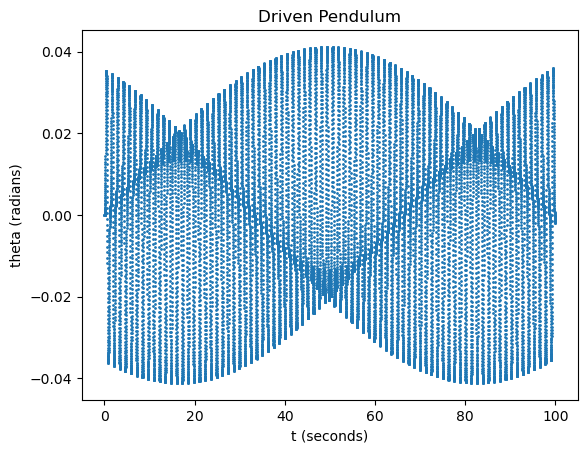

In [5]:
# part a
# define functions
def f(r,t):
    theta = r[0]
    omega = r[1]
    
    # define actual differential equations
    ftheta = omega
    fomega = -g/l * np.sin(theta) + C*np.cos(theta)*np.sin(Omega*t)

    # return vector array of functions
    return np.array([ftheta,fomega], float)


# defining constants
t1 = 0.0 # s
t2 = 100.0 # s
N = 20000
h = (t2-t1) / N

l = 0.10 # m, 10 cm
C = 2 # s^-1
Omega = 5 # s^-1
g = 9.81 # m/s^2

tpts = np.arange(t1,t2+h, h)

r = np.array([0, 0], float) # starting position
thetapts = np.zeros(len(tpts))
omegapts = np.zeros(len(tpts))

# loop to apply fourt-order rune-kutta
for i in range(len(tpts)):
    thetapts[i] = r[0]
    omegapts[i] = r[1]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
plt.scatter(tpts,thetapts,s=1) 
plt.xlabel("t (seconds)")
plt.ylabel("theta (radians)")
plt.title("Driven Pendulum")

plt.show()

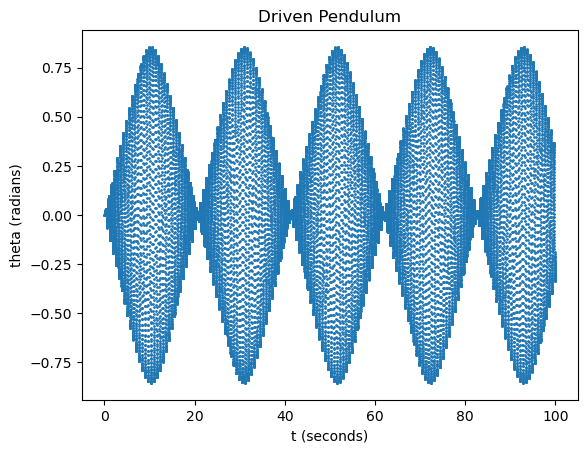

In [6]:
# part b
# defining constants
t1 = 0.0 # s
t2 = 100.0 # s
N = 20000
h = (t2-t1) / N

l = 0.10 # m, 10 cm
C = 2 # s^-1

g = 9.81 # m/s^2

Omega = np.sqrt(g/l) # s^-1

tpts = np.arange(t1,t2+h, h)

r = np.array([0, 0], float) # starting position
thetapts = np.zeros(len(tpts))
omegapts = np.zeros(len(tpts))

# loop to apply fourth-order rune-kutta
for i in range(len(tpts)):
    thetapts[i] = r[0]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
plt.scatter(tpts,thetapts,s=1) 
plt.xlabel("t (seconds)")
plt.ylabel("theta (radians)")
plt.title("Driven Pendulum")

plt.show()

#### Explanation:

For part (a), the following equations defined within a function:
$$\frac{d\theta}{dt} = \omega $$
$$\frac{d\omega}{dt} = -\frac{g}{l} \sin\theta + C\cos\theta\sin\Omega t $$

I first defined the constants detailed within the book problem and established an array to analyze time points between $t=0$ and $t=100$ seconds. I then applied the 4th order Runge-Kutta method and continuously updated an array of the pendulum's theta values. This array was then used in conjecture to plot and visualize the oscillatory pattern of the function.

What I believe is happening physically is the driving frequency is slightly off from the system's natural frequency which is preventing neat oscillations where each 'cycle' begins with zero motion. This is what we are looking for in part (b).


To complete part (b), I had to find the natural frequency of the system, because resonance with the driving force occurs when $\Omega$ approaches the natural frequency.

The equation describing the system from the book is as follows:
$$\frac{d^2\theta}{dt^2} = -\frac{g}{l} \sin\theta + C\cos\theta\sin\Omega t. $$

However, for small angles where $(\sin\theta \approx \theta, \cos\theta \approx 1),$ the equation becomes

$$\frac{d^2\theta}{dt^2} + \frac{g}{l}\theta = C\sin\Omega t. $$

The natural frequency of this driven harmonic oscillator is $\sqrt{\frac{g}{l}}$. When this value is placed equal to its corresponding constant $\Omega$, the resulting plot clearly shows 'beats', which is an expected behavior when at resonance. The amplitude of the cycles is much higher than it was when the natural and driving frequencies were un-synced.

The code in part (b) is functionally the same as in part (a), simply with a single altered constant.

### Problem 4: Exercise 8.8, page 353

### Part a

Treating the rod as a line of length L and mass M and the ball bearing as a point mass m that begins at position $(x,y,0)$. The distance from the ballbearing to a negligible piece of the rod is $r = \sqrt{x^2+y^2+z^2}$. A piece of the rod has mass $dm = \frac{M}{L} dz$.

Applying Newton's law of Gravitation gives:
$$ d\vec{F} = - \frac{Gmdm}{r^2}\hat{r}. $$

Applying symmetry along the rod results in $\hat{r} = \frac{\vec{r}}{r} = \frac{\sqrt{x^2+y^2}}{r}$. Therefore,
$$ dF = \frac{GMm}{Lr^3}\sqrt{x^2+y^2} dz. $$

Integrating along the rod and resubmitting $r = \sqrt{x^2+y^2+z^2}$ results in
$$ F = \frac{GMm}{L}\sqrt{x^2+y^2}\int_{-L/2}^{L/2}\frac{dz}{(x^2+y^2+z^2)^{3/2}}. $$

A simple closed integration gives
$$ F = \frac{GMm}{\sqrt{(x^2+y^2)(x^2+y^2+L^2/4)}}. $$

Rewriting this result with the substitutions $r^2 = x^2+y^2$ and $a^2 = L^2/4$ gives
$$ F = GMm(r^2)^{-1/2}(r^2+a^2)^{1/2}. $$

To avoid complex derivations, convert $F$ into a vector. As the force points radially inward, $\vec{F} = -F(r)\hat{r}$ and $\hat{r} = \frac{\vec{r}}{r} = \frac{<x,y>}{r}. $ Applying these components results in
$$ \vec{F} = -GMm(r^2)^{-1/2}(r^2+a^2)^{1/2}\frac{\vec{r}}{r}. $$

Now apply Newton's second law $\vec{F} = m\vec{a}$ and solve for $\vec{a}$:
$$ \vec{a} = -GM\frac{\vec{r}}{r^2\sqrt{r^2+a^2}}. $$

Replacing the relation $a^2 = L^2/4$ and taking the x- and y-components gives the following second-order equations:
$$ a_x = \frac{d^2x}{dt^2} = -GM\frac{x}{r^2+L^2/4} $$
$$ a_y = \frac{d^2y}{dt^2} = -GM\frac{y}{r^2+L^2/4} $$

where $ r = \sqrt{x^2 + y^2}. $



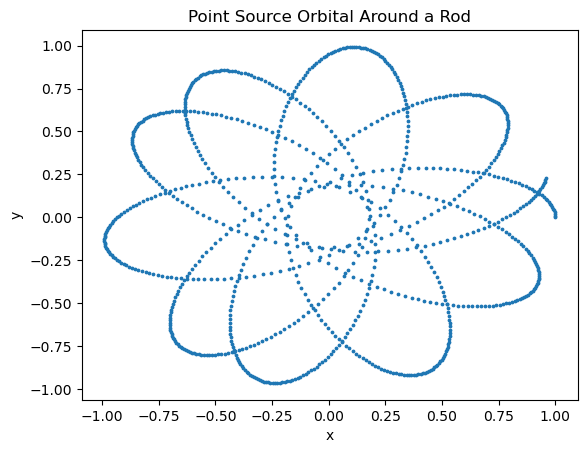

In [7]:
# part b

# define functions
def F(r,t):
    x = r[0]
    y = r[1]
    vx = r[2]
    vy = r[3]
    
    R2 = x**2 + y**2

    # define actual differential equations
    dx = vx
    dvx = -G*M*x / (R2 * np.sqrt(R2 + L**2/4))

    dy = vy
    dvy = -G*M*y / (R2 * np.sqrt(R2 + L**2/4))

    # return vector array of functions
    return np.array([dx,dy,dvx,dvy], float)


# defining constants
t_int = 0.0
t_end = 10.0

G = 1
M = 10
L = 2

# step size
N = 1000
h = (t_end-t_int) / N

times = np.arange(t_int,t_end+h, h)

# initial position, velocity for x and y
r = np.array([1, 0, 0, 1], float) # x,y,vx,vy

xpts = np.zeros(len(times))
ypts = np.zeros(len(times))

# fourth-oder runge-kutta for r
for i in range(len(times)):
    xpts[i] = r[0]
    ypts[i] = r[1]
    
    k1 = h * F(r, times[i])
    k2 = h * F(r+0.5*k1, times[i]+0.5*h)
    k3 = h * F(r+0.5*k2, times[i]+0.5*h)
    k4 = h * F(r+k3, times[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# plotting results
plt.scatter(xpts,ypts,s=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Point Source Orbital Around a Rod")

plt.show()


#### Explanation: 

For part (b) I utilized the follow four equations made from the second-order equations derived in part (a):
$$\frac{dx}{dt} = v_x $$
$$\frac{dv_x}{dt} = -GM\frac{x}{r^2+L^2/4} $$

$$\frac{dy}{dt} = v_y $$
$$\frac{dv_y}{dt} = -GM\frac{y}{r^2+L^2/4} $$

Importantly, the positional vector used when applying the fourth-order Runge-Kutta method contained the information for 4 variables: the position of x, the position of y, the velocity of x, and the velocity of y. This allowed all four equations defined above to be contained within a single function. Keeping all 4 variables together also saves computational power, as Runge-Kutta only needs to be run once to cover all the variable updates. Filling arrays with the x and y coordinates as the orbut progress was straightforwardly completed by having them updates at every iteration of the Runge-Kutta loop.

It is quite interesting that the orbital is visually processing, and quite quickly! The orbit also appears to be stable.